# Panorama Scene Quality Audit Notebook

This notebook audits panorama scenes **before full stitching**.

It estimates whether a scene is:
- likely good
- borderline
- likely to fail

It uses both **image-level** and **adjacent-pair-level** metrics.

## Outputs
- `outputs/audit/image_metrics.csv`
- `outputs/audit/pair_metrics.csv`
- `outputs/audit/scene_metrics.csv`
- visualizations of keypoints, matches, and inliers


In [1]:
from __future__ import annotations

import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from dataclasses import dataclass, asdict


def find_project_root(start: Path) -> Path:
    candidates = [start.resolve(), start.resolve().parent]
    for candidate in candidates:
        if (candidate / "data" / "raw").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/raw")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from project_utils.panorama_dataset import list_scene_dirs, ordered_scene_files

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["image.cmap"] = "gray"

## Configuration

Edit these paths and thresholds for your project.


In [2]:
DATA_ROOT = PROJECT_ROOT / "data" / "raw"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "audit"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / "keypoints").mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / "matches").mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / "inliers").mkdir(parents=True, exist_ok=True)

VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

FEATURE_METHOD = "orb"  # "orb" or "sift"
ORB_NFEATURES = 3000
RATIO_TEST = 0.75
RANSAC_REPROJ_THRESHOLD = 5.0
MIN_GOOD_MATCHES_FOR_H = 10
SAVE_VISUALS = False

THRESH = {
    "min_blur_score": 80.0,
    "min_keypoints": 150,
    "min_good_matches": 40,
    "min_inliers": 20,
    "min_inlier_ratio": 0.35,
    "max_reproj_error": 4.0,
    "min_overlap_ratio": 0.10,
    "max_brightness_gap": 50.0
}

SCENE_THRESH = {
    "good_min_pair_score": 0.65,
    "borderline_min_pair_score": 0.40
}

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT =", DATA_ROOT)
print("OUTPUT_ROOT =", OUTPUT_ROOT)
print("SAVE_VISUALS =", SAVE_VISUALS)

PROJECT_ROOT = F:\CV\School\Project
DATA_ROOT = F:\CV\School\Project\data\raw
OUTPUT_ROOT = F:\CV\School\Project\outputs\audit
SAVE_VISUALS = False


## Helper functions

In [3]:
def list_image_files(scene_dir: Path):
    ordered_files, _, _, _ = ordered_scene_files(scene_dir)
    return ordered_files


def list_reference_files(scene_dir: Path):
    _, reference_files, _, _ = ordered_scene_files(scene_dir)
    return reference_files


def load_bgr(path: Path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path}")
    return img


def to_gray(bgr):
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)


def brightness_mean(gray):
    return float(gray.mean())


def contrast_std(gray):
    return float(gray.std())


def blur_score_laplacian(gray):
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())


def make_feature_detector(method="orb"):
    method = method.lower()
    if method == "orb":
        return cv2.ORB_create(nfeatures=ORB_NFEATURES)
    if method == "sift":
        if hasattr(cv2, "SIFT_create"):
            return cv2.SIFT_create()
        raise RuntimeError("SIFT is not available in this OpenCV build.")
    raise ValueError("method must be 'orb' or 'sift'")


def detect_and_describe(gray, method="orb"):
    detector = make_feature_detector(method)
    kp, des = detector.detectAndCompute(gray, None)
    if kp is None:
        kp = []
    return kp, des


def make_matcher(method="orb"):
    method = method.lower()
    if method == "orb":
        return cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    if method == "sift":
        return cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    raise ValueError("method must be 'orb' or 'sift'")


def knn_ratio_match(des1, des2, method="orb", ratio=0.75):
    if des1 is None or des2 is None or len(des1) == 0 or len(des2) == 0:
        return [], []
    matcher = make_matcher(method)
    knn = matcher.knnMatch(des1, des2, k=2)
    good = []
    for pair in knn:
        if len(pair) < 2:
            continue
        m, n = pair
        if m.distance < ratio * n.distance:
            good.append(m)
    return knn, good


def keypoints_to_xy(kp, matches, query=True):
    pts = []
    for m in matches:
        idx = m.queryIdx if query else m.trainIdx
        pts.append(kp[idx].pt)
    return np.float32(pts).reshape(-1, 1, 2)


def estimate_homography(kp1, kp2, good_matches, reproj_thresh=5.0):
    if len(good_matches) < MIN_GOOD_MATCHES_FOR_H:
        return None, None
    src_pts = keypoints_to_xy(kp1, good_matches, query=True)
    dst_pts = keypoints_to_xy(kp2, good_matches, query=False)
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, reproj_thresh)
    return H, mask


def reprojection_error(kp1, kp2, matches, H, inlier_mask):
    if H is None or inlier_mask is None:
        return float("inf")
    mask = inlier_mask.ravel().astype(bool)
    if mask.sum() == 0:
        return float("inf")
    inlier_matches = [m for m, keep in zip(matches, mask) if keep]
    src = keypoints_to_xy(kp1, inlier_matches, query=True)
    dst = keypoints_to_xy(kp2, inlier_matches, query=False)
    proj = cv2.perspectiveTransform(src, H)
    err = np.linalg.norm(proj - dst, axis=2).reshape(-1)
    return float(err.mean()) if len(err) else float("inf")


def estimate_overlap_ratio(shape1, shape2, H):
    h1, w1 = shape1[:2]
    h2, w2 = shape2[:2]
    mask1 = np.ones((h1, w1), dtype=np.uint8) * 255
    warped = cv2.warpPerspective(mask1, H, (w2, h2))
    overlap_pixels = np.count_nonzero(warped > 0)
    total_pixels_dest = h2 * w2
    return float(overlap_pixels / max(total_pixels_dest, 1))


def draw_keypoints_image(bgr, kp):
    return cv2.drawKeypoints(
        bgr, kp, None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
        color=(0, 255, 0)
    )


def draw_matches_image(img1, kp1, img2, kp2, matches, max_draw=80):
    draw_matches = sorted(matches, key=lambda m: m.distance)[:max_draw]
    return cv2.drawMatches(
        img1, kp1, img2, kp2, draw_matches, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )


def draw_inlier_matches_image(img1, kp1, img2, kp2, matches, inlier_mask, max_draw=80):
    if inlier_mask is None:
        return draw_matches_image(img1, kp1, img2, kp2, [], max_draw=max_draw)
    mask = inlier_mask.ravel().astype(bool)
    inlier_matches = [m for m, keep in zip(matches, mask) if keep]
    return draw_matches_image(img1, kp1, img2, kp2, inlier_matches, max_draw=max_draw)


def save_bgr(path: Path, img):
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), img)


def show_bgr(bgr, title=""):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()


def normalize_score(value, good_if_high=True, good_threshold=1.0, bad_threshold=0.0):
    if good_if_high:
        if value >= good_threshold:
            return 1.0
        if value <= bad_threshold:
            return 0.0
        return float((value - bad_threshold) / max(good_threshold - bad_threshold, 1e-9))
    else:
        if value <= good_threshold:
            return 1.0
        if value >= bad_threshold:
            return 0.0
        return float((bad_threshold - value) / max(bad_threshold - good_threshold, 1e-9))

## Scoring logic

This is a simple, interpretable rule-based screener.
You should tune these rules on your own development scenes.


In [4]:
def score_image_metrics(blur, n_kp):
    s_blur = normalize_score(
        blur,
        good_if_high=True,
        good_threshold=max(THRESH["min_blur_score"] * 2, THRESH["min_blur_score"] + 1),
        bad_threshold=THRESH["min_blur_score"] * 0.25
    )
    s_kp = normalize_score(
        n_kp,
        good_if_high=True,
        good_threshold=max(THRESH["min_keypoints"] * 2, THRESH["min_keypoints"] + 1),
        bad_threshold=max(20, THRESH["min_keypoints"] * 0.2)
    )
    return 0.5 * s_blur + 0.5 * s_kp

def score_pair_metrics(good_matches, inliers, inlier_ratio, reproj_err, overlap_ratio, brightness_gap):
    s_good = normalize_score(
        good_matches,
        good_if_high=True,
        good_threshold=max(THRESH["min_good_matches"] * 2, THRESH["min_good_matches"] + 1),
        bad_threshold=max(5, THRESH["min_good_matches"] * 0.25)
    )
    s_inliers = normalize_score(
        inliers,
        good_if_high=True,
        good_threshold=max(THRESH["min_inliers"] * 2, THRESH["min_inliers"] + 1),
        bad_threshold=max(4, THRESH["min_inliers"] * 0.25)
    )
    s_ratio = normalize_score(
        inlier_ratio,
        good_if_high=True,
        good_threshold=min(0.75, max(0.50, THRESH["min_inlier_ratio"] + 0.2)),
        bad_threshold=max(0.05, THRESH["min_inlier_ratio"] * 0.3)
    )
    s_reproj = normalize_score(
        reproj_err,
        good_if_high=False,
        good_threshold=THRESH["max_reproj_error"],
        bad_threshold=max(THRESH["max_reproj_error"] * 3, THRESH["max_reproj_error"] + 5)
    )
    s_overlap = normalize_score(
        overlap_ratio,
        good_if_high=True,
        good_threshold=max(0.25, THRESH["min_overlap_ratio"] + 0.15),
        bad_threshold=max(0.01, THRESH["min_overlap_ratio"] * 0.2)
    )
    s_brightness = normalize_score(
        brightness_gap,
        good_if_high=False,
        good_threshold=THRESH["max_brightness_gap"],
        bad_threshold=max(THRESH["max_brightness_gap"] * 2, THRESH["max_brightness_gap"] + 40)
    )
    return float(
        0.15 * s_good +
        0.15 * s_inliers +
        0.25 * s_ratio +
        0.20 * s_reproj +
        0.15 * s_overlap +
        0.10 * s_brightness
    )

def classify_pair(row):
    if not row["homography_ok"]:
        return "likely_fail"
    hard_fail = (
        row["good_matches"] < THRESH["min_good_matches"] or
        row["inliers"] < THRESH["min_inliers"] or
        row["inlier_ratio"] < THRESH["min_inlier_ratio"] or
        row["reprojection_error"] > THRESH["max_reproj_error"] or
        row["overlap_ratio"] < THRESH["min_overlap_ratio"]
    )
    if hard_fail:
        return "likely_fail"
    if row["pair_score"] >= SCENE_THRESH["good_min_pair_score"]:
        return "likely_good"
    return "borderline"

def classify_scene(pair_rows):
    if len(pair_rows) == 0:
        return "likely_fail", 0.0, None
    min_score_row = min(pair_rows, key=lambda r: r["pair_score"])
    min_score = float(min_score_row["pair_score"])
    weakest_pair = min_score_row["pair_id"]
    if min_score >= SCENE_THRESH["good_min_pair_score"]:
        return "likely_good", min_score, weakest_pair
    if min_score >= SCENE_THRESH["borderline_min_pair_score"]:
        return "borderline", min_score, weakest_pair
    return "likely_fail", min_score, weakest_pair


In [5]:
@dataclass
class ImageMetric:
    scene_id: str
    image_id: str
    path: str
    width: int
    height: int
    brightness_mean: float
    contrast_std: float
    blur_score: float
    keypoints: int
    image_quality_score: float


@dataclass
class PairMetric:
    scene_id: str
    pair_id: str
    img_a: str
    img_b: str
    raw_knn_pairs: int
    good_matches: int
    homography_ok: bool
    inliers: int
    inlier_ratio: float
    reprojection_error: float
    overlap_ratio: float
    brightness_gap: float
    pair_score: float
    pair_label: str


def audit_scene(scene_dir: Path, feature_method=FEATURE_METHOD, save_visuals=SAVE_VISUALS):
    image_files, reference_files, _, used_meta_order = ordered_scene_files(scene_dir)
    scene_id = scene_dir.name

    if len(image_files) < 2:
        raise ValueError(f"{scene_id}: need at least 2 ordered images, found {len(image_files)}")

    imgs_bgr = [load_bgr(p) for p in image_files]
    imgs_gray = [to_gray(im) for im in imgs_bgr]

    image_rows = []
    kps = []
    dess = []

    for path, bgr, gray in zip(image_files, imgs_bgr, imgs_gray):
        kp, des = detect_and_describe(gray, method=feature_method)
        kps.append(kp)
        dess.append(des)

        blur = blur_score_laplacian(gray)
        bright = brightness_mean(gray)
        cont = contrast_std(gray)
        n_kp = len(kp)
        img_score = score_image_metrics(blur, n_kp)

        image_rows.append(asdict(ImageMetric(
            scene_id=scene_id,
            image_id=path.stem,
            path=str(path),
            width=bgr.shape[1],
            height=bgr.shape[0],
            brightness_mean=bright,
            contrast_std=cont,
            blur_score=blur,
            keypoints=n_kp,
            image_quality_score=img_score
        )))

        if save_visuals:
            out_kp = draw_keypoints_image(bgr, kp)
            save_bgr(OUTPUT_ROOT / "keypoints" / f"{scene_id}_{path.stem}_keypoints.jpg", out_kp)

    pair_rows = []
    for i in range(len(image_files) - 1):
        path_a, path_b = image_files[i], image_files[i + 1]
        gray_a, gray_b = imgs_gray[i], imgs_gray[i + 1]
        bgr_a, bgr_b = imgs_bgr[i], imgs_bgr[i + 1]
        kp_a, kp_b = kps[i], kps[i + 1]
        des_a, des_b = dess[i], dess[i + 1]

        knn, good = knn_ratio_match(des_a, des_b, method=feature_method, ratio=RATIO_TEST)
        H, mask = estimate_homography(kp_a, kp_b, good, reproj_thresh=RANSAC_REPROJ_THRESHOLD)
        homography_ok = H is not None and mask is not None

        if homography_ok:
            inliers = int(mask.sum())
            inlier_ratio = float(inliers / max(len(good), 1))
            reproj = reprojection_error(kp_a, kp_b, good, H, mask)
            overlap = estimate_overlap_ratio(gray_a.shape, gray_b.shape, H)
        else:
            inliers = 0
            inlier_ratio = 0.0
            reproj = float("inf")
            overlap = 0.0

        bright_gap = abs(brightness_mean(gray_a) - brightness_mean(gray_b))
        pair_score = score_pair_metrics(
            good_matches=len(good),
            inliers=inliers,
            inlier_ratio=inlier_ratio,
            reproj_err=reproj,
            overlap_ratio=overlap,
            brightness_gap=bright_gap
        ) if homography_ok else 0.0

        row = asdict(PairMetric(
            scene_id=scene_id,
            pair_id=f"{path_a.stem}__{path_b.stem}",
            img_a=path_a.stem,
            img_b=path_b.stem,
            raw_knn_pairs=len(knn),
            good_matches=len(good),
            homography_ok=bool(homography_ok),
            inliers=inliers,
            inlier_ratio=inlier_ratio,
            reprojection_error=reproj,
            overlap_ratio=overlap,
            brightness_gap=bright_gap,
            pair_score=pair_score,
            pair_label=""
        ))
        row["pair_label"] = classify_pair(row)
        pair_rows.append(row)

        if save_visuals:
            match_img = draw_matches_image(bgr_a, kp_a, bgr_b, kp_b, good, max_draw=80)
            save_bgr(OUTPUT_ROOT / "matches" / f"{scene_id}_{path_a.stem}__{path_b.stem}_matches.jpg", match_img)

            inlier_img = draw_inlier_matches_image(bgr_a, kp_a, bgr_b, kp_b, good, mask, max_draw=80)
            save_bgr(OUTPUT_ROOT / "inliers" / f"{scene_id}_{path_a.stem}__{path_b.stem}_inliers.jpg", inlier_img)

    scene_label, scene_score, weakest_pair = classify_scene(pair_rows)

    scene_row = {
        "scene_id": scene_id,
        "num_images": len(image_files),
        "num_reference_files": len(reference_files),
        "reference_files": ", ".join(path.name for path in reference_files),
        "used_meta_order": bool(used_meta_order),
        "avg_brightness": float(np.mean([r["brightness_mean"] for r in image_rows])),
        "avg_contrast": float(np.mean([r["contrast_std"] for r in image_rows])),
        "min_blur_score": float(np.min([r["blur_score"] for r in image_rows])),
        "avg_keypoints": float(np.mean([r["keypoints"] for r in image_rows])),
        "avg_good_matches": float(np.mean([r["good_matches"] for r in pair_rows])) if pair_rows else 0.0,
        "avg_inlier_ratio": float(np.mean([r["inlier_ratio"] for r in pair_rows])) if pair_rows else 0.0,
        "max_reprojection_error": float(np.max([r["reprojection_error"] for r in pair_rows if np.isfinite(r["reprojection_error"])])) if any(np.isfinite(r["reprojection_error"]) for r in pair_rows) else float("inf"),
        "scene_score": float(scene_score),
        "scene_label": scene_label,
        "weakest_pair": weakest_pair
    }

    return image_rows, pair_rows, scene_row

## Run the audit on all scenes

In [6]:
scene_dirs = list_scene_dirs(DATA_ROOT)
print(f"Found {len(scene_dirs)} scene folders.")

all_image_rows = []
all_pair_rows = []
all_scene_rows = []
errors = []

for scene_dir in scene_dirs:
    try:
        image_rows, pair_rows, scene_row = audit_scene(scene_dir, feature_method=FEATURE_METHOD, save_visuals=SAVE_VISUALS)
        all_image_rows.extend(image_rows)
        all_pair_rows.extend(pair_rows)
        all_scene_rows.append(scene_row)
        print(f"[OK] {scene_dir.name}: {scene_row['scene_label']} (score={scene_row['scene_score']:.3f})")
    except Exception as e:
        errors.append({"scene_id": scene_dir.name, "error": str(e)})
        print(f"[ERR] {scene_dir.name}: {e}")

df_images = pd.DataFrame(all_image_rows)
df_pairs = pd.DataFrame(all_pair_rows)
df_scenes = pd.DataFrame(all_scene_rows)
df_errors = pd.DataFrame(errors)

df_images.to_csv(OUTPUT_ROOT / "image_metrics.csv", index=False)
df_pairs.to_csv(OUTPUT_ROOT / "pair_metrics.csv", index=False)
df_scenes.to_csv(OUTPUT_ROOT / "scene_metrics.csv", index=False)
df_errors.to_csv(OUTPUT_ROOT / "errors.csv", index=False)

print("\nSaved CSV files to:", OUTPUT_ROOT.resolve())


Found 19 scene folders.
[OK] scene_01: likely_good (score=0.887)
[OK] scene_02: likely_good (score=1.000)
[OK] scene_03: likely_good (score=0.768)
[OK] scene_04: borderline (score=0.511)
[OK] scene_05: likely_good (score=0.859)
[OK] scene_06: borderline (score=0.585)
[OK] scene_07: borderline (score=0.538)
[OK] scene_08: likely_good (score=1.000)
[OK] scene_10: likely_good (score=0.743)
[OK] scene_11: likely_good (score=0.781)
[OK] scene_12: likely_good (score=1.000)
[OK] scene_13: likely_good (score=0.696)
[OK] scene_14: borderline (score=0.581)
[OK] scene_15: likely_good (score=0.695)
[OK] scene_16: borderline (score=0.585)
[OK] scene_17: likely_good (score=0.927)
[OK] scene_18: borderline (score=0.564)
[OK] scene_19: likely_fail (score=0.000)
[OK] scene_20: borderline (score=0.580)

Saved CSV files to: F:\CV\School\Project\outputs\audit


## View the summary tables

In [7]:
if not df_scenes.empty:
    display(df_scenes.sort_values(["scene_label", "scene_score"], ascending=[True, False]))
else:
    print("No scene data.")

print("\nWorst pairs:")
if not df_pairs.empty:
    display(df_pairs.sort_values("pair_score", ascending=True).head(30))
else:
    print("No pair data.")


,scene_id,num_images,num_reference_files,reference_files,used_meta_order,avg_brightness,avg_contrast,min_blur_score,avg_keypoints,avg_good_matches,avg_inlier_ratio,max_reprojection_error,scene_score,scene_label,weakest_pair
5,scene_06,4,0,,True,103.864255,58.302092,203.234547,3000.000000,25.000000,0.424956,1.200826,0.585265,borderline,img_001__img_002
14,scene_16,4,1,overall.jpg,True,152.305450,25.978930,5.562817,2235.750000,103.666667,0.469979,1.981668,0.584581,borderline,img_003__img_004
12,scene_14,4,0,,True,117.961443,57.557683,87.528501,3000.000000,63.000000,0.246148,1.598027,0.580811,borderline,img_003__img_004
18,scene_20,6,0,,True,123.391274,52.746655,60.523320,3000.000000,63.800000,0.276089,2.017154,0.579916,borderline,img_005__img_006
16,scene_18,9,0,,True,85.398655,60.931731,6.039238,3000.000000,93.625000,0.306457,2.352968,0.564209,borderline,img_003__img_004
6,scene_07,3,0,,True,124.645892,76.538312,67.175034,3000.000000,14.000000,0.299465,0.000000,0.538199,borderline,img_001__img_002
3,scene_04,3,0,,True,67.220320,80.754049,162.326085,3000.000000,23.000000,0.266667,1.924500,0.510977,borderline,img_001__img_002
17,scene_19,6,0,,True,104.054556,56.823456,5.213585,3000.000000,72.400000,0.263965,1.940546,0.000000,likely_fail,img_002__img_003
1,scene_02,3,0,,True,100.755433,55.059436,7.835386,3000.000000,135.500000,0.652019,1.601805,1.000000,likely_good,img_001__img_002
7,scene_08,3,0,,True,132.671096,51.815808,114.644593,3000.000000,146.000000,0.725038,1.741287,1.000000,likely_good,img_001__img_002



Worst pairs:


,scene_id,pair_id,img_a,img_b,raw_knn_pairs,good_matches,homography_ok,inliers,inlier_ratio,reprojection_error,overlap_ratio,brightness_gap,pair_score,pair_label
51,scene_19,img_002__img_003,img_002,img_003,3000,4,False,0,0.000000,inf,0.000000,15.160832,0.000000,likely_fail
54,scene_19,img_005__img_006,img_005,img_006,3000,7,False,0,0.000000,inf,0.000000,8.443692,0.000000,likely_fail
10,scene_04,img_001__img_002,img_001,img_002,3000,25,True,5,0.200000,0.227063,0.212377,8.346798,0.510977,likely_fail
17,scene_07,img_001__img_002,img_001,img_002,3000,17,True,4,0.235294,0.000000,0.288966,9.986579,0.538199,likely_fail
44,scene_18,img_003__img_004,img_003,img_004,3000,18,True,5,0.277778,0.796103,0.961266,15.607859,0.564209,likely_fail
59,scene_20,img_005__img_006,img_005,img_006,3000,41,True,8,0.195122,2.017154,0.988362,11.698278,0.579916,likely_fail
32,scene_14,img_003__img_004,img_003,img_004,3000,53,True,8,0.150943,1.598027,0.947010,7.289444,0.580811,likely_fail
48,scene_18,img_007__img_008,img_007,img_008,3000,70,True,6,0.085714,1.274532,0.709073,11.966675,0.582857,likely_fail
46,scene_18,img_005__img_006,img_005,img_006,3000,50,True,9,0.180000,2.352968,0.233834,17.959300,0.584449,likely_fail
39,scene_16,img_003__img_004,img_003,img_004,2336,52,True,17,0.326923,1.855594,0.048330,7.158672,0.584581,likely_fail


## Plots

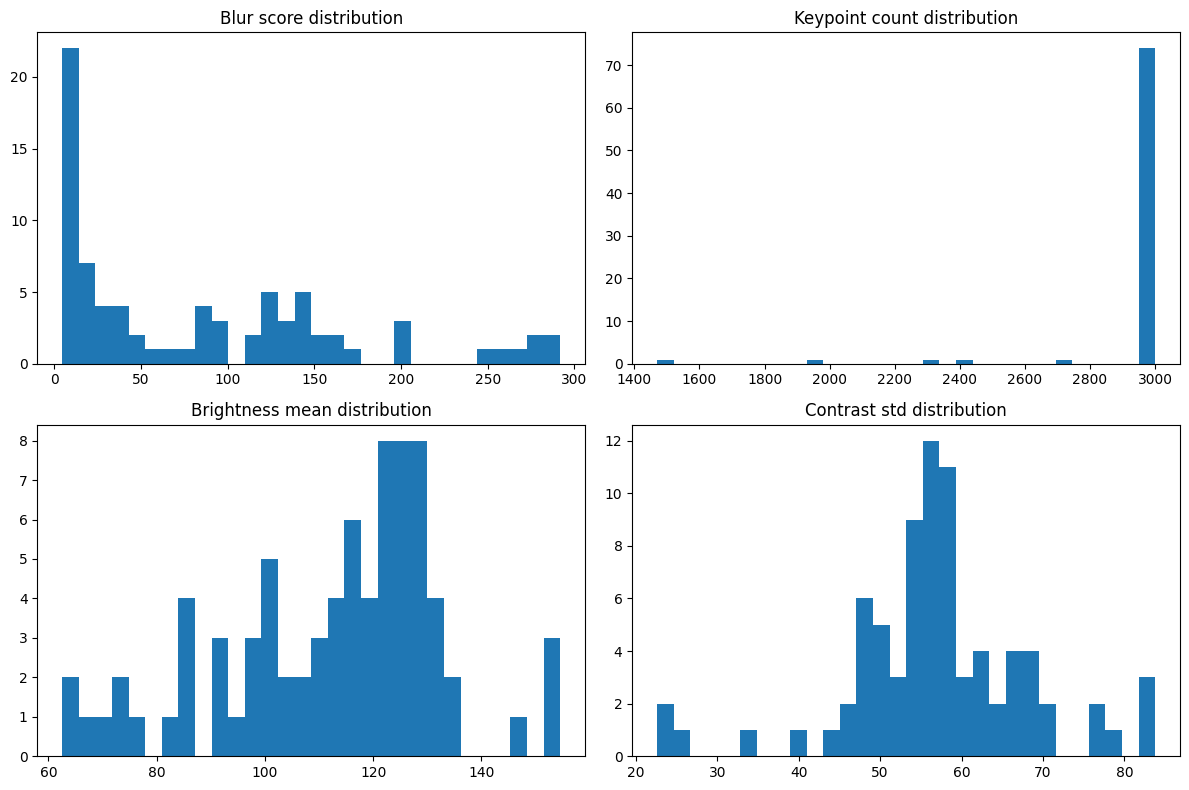

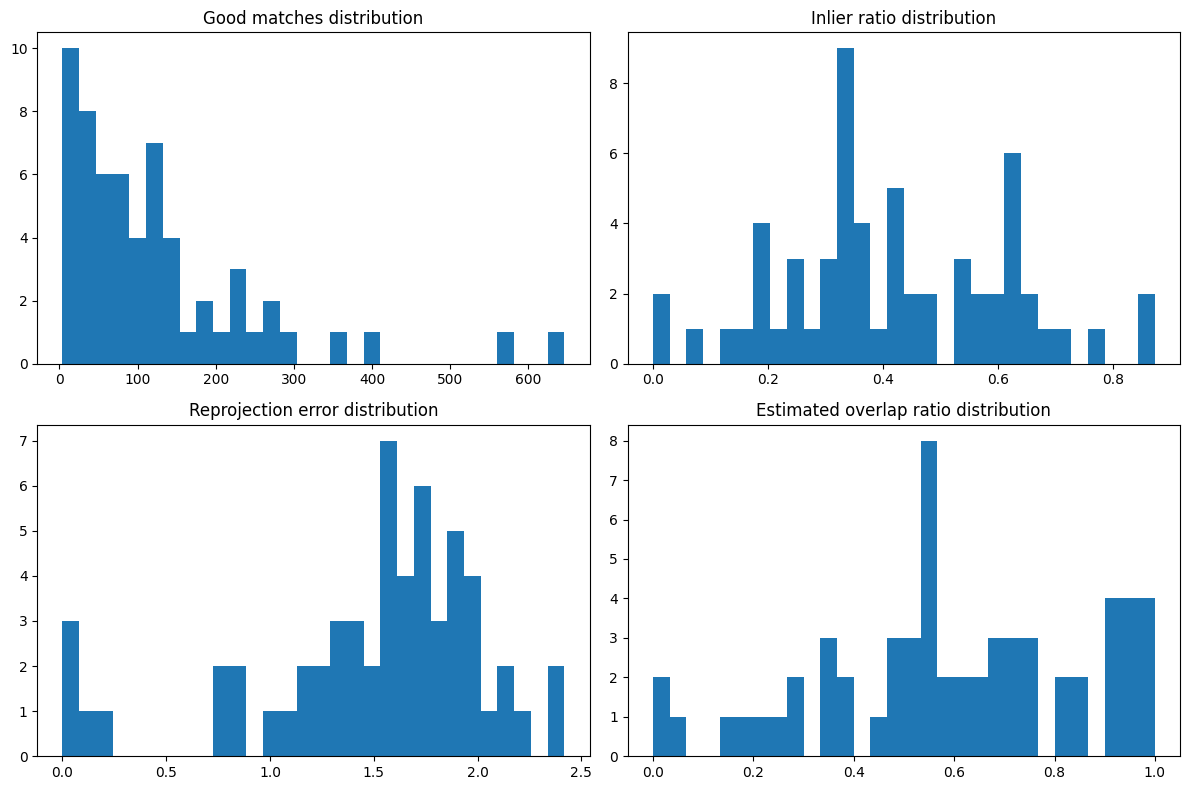

In [8]:
if not df_images.empty:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0, 0].hist(df_images["blur_score"], bins=30)
    axes[0, 0].set_title("Blur score distribution")
    axes[0, 1].hist(df_images["keypoints"], bins=30)
    axes[0, 1].set_title("Keypoint count distribution")
    axes[1, 0].hist(df_images["brightness_mean"], bins=30)
    axes[1, 0].set_title("Brightness mean distribution")
    axes[1, 1].hist(df_images["contrast_std"], bins=30)
    axes[1, 1].set_title("Contrast std distribution")
    plt.tight_layout()
    plt.show()

if not df_pairs.empty:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0, 0].hist(df_pairs["good_matches"], bins=30)
    axes[0, 0].set_title("Good matches distribution")
    axes[0, 1].hist(df_pairs["inlier_ratio"], bins=30)
    axes[0, 1].set_title("Inlier ratio distribution")
    valid_reproj = df_pairs[np.isfinite(df_pairs["reprojection_error"])]["reprojection_error"]
    axes[1, 0].hist(valid_reproj, bins=30)
    axes[1, 0].set_title("Reprojection error distribution")
    axes[1, 1].hist(df_pairs["overlap_ratio"], bins=30)
    axes[1, 1].set_title("Estimated overlap ratio distribution")
    plt.tight_layout()
    plt.show()


## Inspect one scene manually after auto-audit

Recommended workflow:
1. run the automatic audit
2. inspect only **borderline scenes**
3. inspect a few **failure scenes** for report examples


In [9]:
SCENE_TO_INSPECT = None  # e.g. "scene_03"

if SCENE_TO_INSPECT:
    scene_dir = DATA_ROOT / SCENE_TO_INSPECT
    files = list_image_files(scene_dir)
    reference_files = list_reference_files(scene_dir)
    print("Ordered files:", [f.name for f in files])
    if reference_files:
        print("Reference files (excluded from audit chain):", [f.name for f in reference_files])

    for f in files:
        img = load_bgr(f)
        show_bgr(img, title=f"{SCENE_TO_INSPECT} - {f.name}")

    if reference_files:
        for f in reference_files:
            img = load_bgr(f)
            show_bgr(img, title=f"{SCENE_TO_INSPECT} - reference - {f.name}")

    if not df_pairs.empty:
        display(df_pairs[df_pairs["scene_id"] == SCENE_TO_INSPECT].sort_values("pair_score"))

## Suggested interpretation

### Use as main success scenes
- all adjacent pairs estimate homography successfully
- inlier ratio is decent
- overlap is not tiny
- blur is not severe

### Borderline scenes
- one pair is weak but not completely broken
- exposure gap is large
- geometry works, but score is not strong

### Failure scenes
- homography fails
- low texture causes too few keypoints
- repeated patterns give weak geometry
- parallax causes unstable reprojection error
- moving objects are visually obvious
